In [5]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Find any file starting with CRMLSSold
file_pattern = "../data/CRMLSSold*.csv"
all_files = glob.glob(file_pattern)

# Sort to chronological order
all_files.sort()

Found 12 files:
['../data/CRMLSSold202506.csv', '../data/CRMLSSold202507.csv', '../data/CRMLSSold202508.csv', '../data/CRMLSSold202509.csv', '../data/CRMLSSold202510.csv', '../data/CRMLSSold202511.csv', '../data/CRMLSSold202512.csv', '../data/CRMLSSold202601.csv', '../data/CRMLSSold202602.csv', '../data/CRMLSSold202603.csv', '../data/CRMLSSold202604.csv', '../data/CRMLSSold202605.csv']


In [9]:
# Storing monthly dataframes
dfs = []

# Loop through each file path, read it, and append it list
for file in all_files:
    temp_df = pd.read_csv(file)
    dfs.append(temp_df)

# Stack all dataframes into one DataFrame
df = pd.concat(dfs, ignore_index=True)

# Print the total dimensions of raw data
print("Raw dataset shape:", df.shape)

/var/folders/5w/x58jx_y54d3bykbyg90v68mm0000gn/T/ipykernel_84547/3780114670.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)
/var/folders/5w/x58jx_y54d3bykbyg90v68mm0000gn/T/ipykernel_84547/3780114670.py:6: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)


Raw dataset shape: (258669, 78)


In [10]:
# Print first 5 rows
df.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,SanDiego,SanDiego,NaN,False,NaN,NaN,False,5000.0,542181398,ops@downtowncondoguys.com,...,NaN,NaN,NaN,NaN,1.0,NaN,92101,0.0,NaN,NaN
1,PacificWest,PacificWest,NaN,True,NaN,NaN,NaN,110000.0,540760713,nowjoanne@gmail.com,...,NaN,355936.0,NaN,False,NaN,NaN,93550,0.0,355936.0,NaN
2,SouthwestLosAngeles,SouthwestLosAngeles,NaN,True,NaN,NaN,NaN,1545000.0,525608302,Austin_Brown@pacificplayarealty.com,...,88x231,20212.0,NaN,False,NaN,NaN,90008,NaN,20212.0,NaN
3,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,False,889000.0,523319952,hutton@cbappteam.com,...,NaN,9600.0,0.0,True,2.0,Rim of the World,92352,0.0,9600.0,NaN
4,SanDiego,SanDiego,Laminate,True,NaN,NaN,False,1700.0,518730969,mannybehar@yahoo.com,...,NaN,NaN,NaN,NaN,0.0,NaN,92126,0.0,NaN,NaN


In [ ]:
# Filter using the same string
filtered_df = df[
    (df["PropertyType"] == "Residential")
    & (df["PropertySubType"] == "SingleFamilyResidence")
]

print("Filtered dataset shape:", filtered_df.shape)

Filtered dataset shape: (130220, 78)


In [11]:
# Filter and save to a new filtered dataframe
filtered_df = df[
    (df["PropertyType"] == "Residential") & 
    (df["PropertySubType"] == "Single Family Residence")
]

print("Filtered dataset shape:", filtered_df.shape)

Filtered dataset shape: (0, 78)


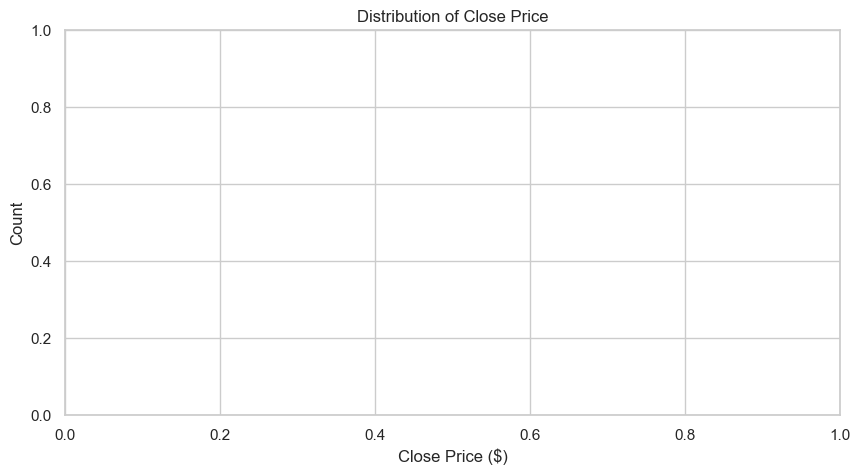

In [12]:
# Plot the distribution of ClosePrice
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.histplot(filtered_df["ClosePrice"], kde=True, bins=50, color="blue")
plt.title("Distribution of Close Price")
plt.xlabel("Close Price ($)")
plt.ylabel("Count")
plt.show()